In [110]:
%pip install adjustText

In [268]:
# Create new folder - Week2
# Upload glassdoorReviews.csv into that folder

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem.snowball import SnowballStemmer
snow_stemmer = SnowballStemmer(language='english')
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
import statsmodels.api as sm
from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.model_selection import ShuffleSplit
from adjustText import adjust_text

# Change path
os.chdir('/content/Week2/')
# check path
print(os.getcwd())


#glassdoor = pd.read_csv('glassdoorReviews.csv')

# if you run into the error below:
# ParserError: Error tokenizing data. C error: EOF inside string starting at row

glassdoor = pd.read_csv('glassdoorReviews.csv', error_bad_lines=False, engine="python")

# On macs that do not use the new silicon chip, you can use pyreadr
# glassdoor = pyreadr.read_r('glassdoorReviews.RDS')
# glassdoor = pd.DataFrame(glassdoor[None])

# done!

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
<ipython-input-268-0fff99b3863a>:35: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  glassdoor = pd.read_csv('glassdoorReviews.csv', error_bad_lines=False, engine="python")


/content/Week2


In [269]:
# All functions are typically located near top of script

def stemming_tokenizer(str_input):

    # This function will be used to override basic preprocessing steps in TfidfVrctorizer

    words = re.sub(r"[^A-Za-z]", " ", str_input).lower().split()
    words = [snow_stemmer.stem(word) for word in words]

    return words

def TAB_dfm(text, ngrams_range = (1,2),
                stop_words = 'english', min_prop = .01,
                max_features=None):

  # TfidfVectorizer and CountVectorizer removes punctuation automatically
  # we also pass an earlier stemming_tokenizer function to the text
  # stopword options are either 'english' or False currently

  if stop_words == 'english':
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        stop_words = stop_words,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
        )
  else:
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
    )

  X = vec.fit_transform(text)

  df = round(pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out()),2)

  return df

# Kendal tao accuracy is available with sciPy

def kendall_acc(x,y,percentage = True):

  tau, p_value = stats.kendalltau(x, y)
  tau_acc = .5+tau/2
  tau_se = np.sqrt((tau_acc*(1 - tau_acc))/len(x))
  report = pd.DataFrame([tau_acc, tau_acc - 1.96 * tau_se, tau_acc + 1.96 * tau_se],
                        index = ['acc', 'lower', 'upper']).T
  report = round(report,4)

  if percentage is True:
    report = report * 100

  return report

(97865, 18)
['Unnamed: 0', 'company', 'date', 'location', 'job_title', 'status', 'summary', 'pros', 'cons', 'advice_to_mgmt', 'overall', 'work_balance', 'culture_values', 'career_opps', 'comp_benefit', 'senior_management', 'helpful_count', 'FAANG']
company    FAANG
amazon     1        26430
microsoft  1        17930
apple      1        12950
startup_4  0        11758
startup_6  0         8172
google     1         7819
startup_2  0         5863
startup_1  0         3468
facebook   1         1590
netflix    1          810
startup_5  0          698
startup_3  0          377
dtype: int64


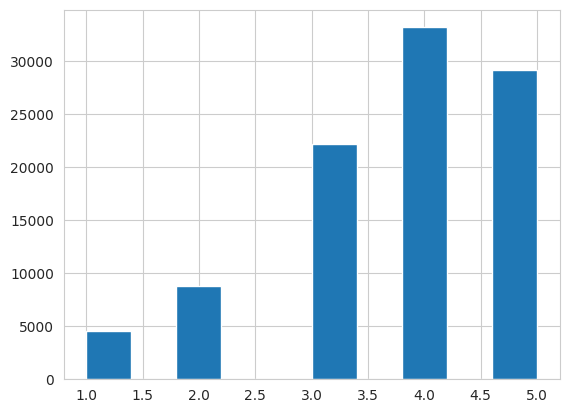

In [270]:
# let's see what is in the data
# result is a dictionary where keys are the name of objects and the values python
# objects

# print(glassdoor)
print(glassdoor.shape)
print(list(glassdoor))

# Split in categories - some big companies, some smaller ones
print(glassdoor[['company','FAANG']].value_counts())

# Other important metadata - Overall rating
plt.hist(glassdoor['overall'])
plt.show()

Note that when loading in large datasets to colab, it takes some time!  You will know it is done when all twelve companies appear in the table above (like the screenshot below). If they are not all there, then give it a minute or two to keep loading, and then re-run the code block above.

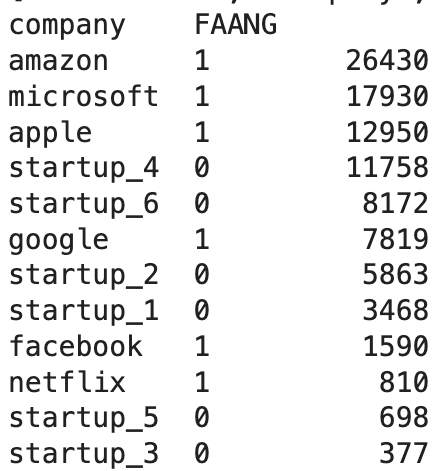

remove below

<ipython-input-271-0d53ba6d69b0>:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels, size = 12, rotation = 45)


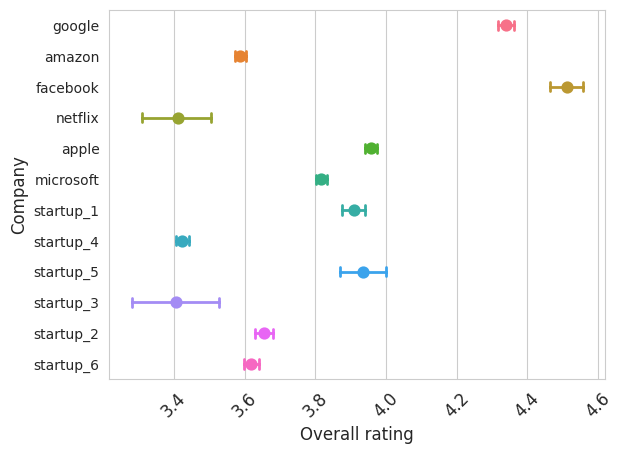

In [271]:
# Lets try something new for plotting..

# Seaborn is a wraper around matplotlib meaning you can still use the same
# matplotlib functions but also incorporate seaborn styles
# Note that we can just plot the raw data without having to aggregate the data first

sns.set_style("whitegrid")

ax = sns.pointplot(y="company", x="overall",
                 hue="company", # You can use hue to change colour by
                 estimator=np.mean, # height of bar
                 data=glassdoor, # dataset
                 errorbar=('ci', 95), capsize=.3, # controls width of errorbars
                 err_kws={'linewidth': 2}, # controls thickness of errorbars
                 dodge=False) # aligns bars with ticks

# Tidying up the x axis tick labels
_, xlabels = plt.xticks()
ax.set_xticklabels(xlabels, size = 12, rotation = 45)

# removes legend
plt.legend([],[], frameon=False)

plt.xlabel("Overall rating", fontsize = 12)
plt.ylabel("Company", fontsize = 12)
# plt.ylim(3, 5)
plt.show()


In [273]:
glassdoor['pro_wordcount'] = [len(re.sub(r"[^A-Za-z]", " ", i).lower().split()) for i in glassdoor['pros']]
print(glassdoor['pro_wordcount'])

glassdoor['con_wordcount'] = [len(re.sub(r"[^A-Za-z]", " ", i).lower().split()) for i in glassdoor['cons']]
print(glassdoor['con_wordcount'])

0           5
1         158
2         648
3         298
4        1439
         ... 
97860      20
97861       6
97862      23
97863       8
97864       8
Name: pro_wordcount, Length: 97865, dtype: int64
0          5
1        407
2        179
3        512
4        830
        ... 
97860     34
97861      7
97862     26
97863      9
97864      5
Name: con_wordcount, Length: 97865, dtype: int64


In [274]:
# Let's focus on people who actually wrote text in both boxes
# Even that's too big so let's get it down to 40,000 texts
# Note that we shuffle the order first, then grab the first 40,000

gd_small = glassdoor[(glassdoor['pro_wordcount'] > 5) & (glassdoor['con_wordcount'] > 5)]

# get random sample of 40000... for this exercise, feel free to pick a smaller number
# random state allows the same random samples to be chosen. Useful for replicability
gd_small = gd_small.sample(n = 40000, random_state = 42)

# Check we have 40000 rows
print(gd_small.shape)


(40000, 20)


In [ ]:
# Let's just look at amazon for now
gd_amazon = gd_small[gd_small['company'] == 'amazon']

# create our prediction variables
dfm_amazon_pros = TAB_dfm(gd_amazon['pros'], ngrams_range = (1,2))

# Randomly choose 50% for test and 50% for training data
sss = ShuffleSplit(n_splits=1, test_size=0.5)

y_amazon = gd_amazon['overall']
X_amazon_pros = dfm_amazon_pros

sss.get_n_splits(X_amazon_pros, y_amazon)
train_index, test_index = next(sss.split(X_amazon_pros, y_amazon))

X_train_amazon_pros, X_test_amazon_pros = X_amazon_pros.iloc[train_index], X_amazon_pros.iloc[test_index]
y_train_amazon, y_test_amazon = y_amazon.iloc[train_index], y_amazon.iloc[test_index]

# The below is for when we don't have to to any transfer learning
# X_train_amazon_pros, X_test_amazon_pros, y_train_amazon_pros, y_test_amazon_pros = train_test_split(
#     X_amazon_pros, y_amazon, test_size=0.5, random_state=42)

# Put training data into LASSO model
clf_pros = Lasso(alpha = 0.001)

clf_pros.fit(X_train_amazon_pros, y_train_amazon)
test_predict_amazon_pros = clf_pros.predict(X_test_amazon_pros)

# Estimate accuracy
pro_acc = kendall_acc(test_predict_amazon_pros, y_test_amazon)
print(pro_acc)


In [276]:
# Let's do the same thing with the cons text now
dfm_amazon_cons = TAB_dfm(gd_amazon['cons'], ngrams_range = (1,2))

# Randomly choose 50% for test and 50% for training data
X_amazon_cons = dfm_amazon_cons

X_train_amazon_cons, X_test_amazon_cons = X_amazon_cons.iloc[train_index], X_amazon_cons.iloc[test_index]

# Put training data into LASSO model
clf_cons = Lasso(alpha = 0.001)

clf_cons.fit(X_train_amazon_cons, y_train_amazon)
test_predict_amazon_cons = clf_cons.predict(X_test_amazon_cons)

# Estimate accuracy
con_acc = kendall_acc(test_predict_amazon_cons, y_test_amazon)
print(con_acc)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

     acc  lower  upper
0  69.39  68.14  70.64


In [277]:
# Training model on cons data but predicting pros

# we must match the names of variable in both pros and cons
col_heads_pros = set(dfm_amazon_pros)
col_heads_cons = set(dfm_amazon_cons)

col_heads = col_heads_pros.intersection(col_heads_cons)
print(col_heads)

# Training data from cons but subset cons data for where text appears in both pros and cons
X_amazon_cons = dfm_amazon_cons
amazon_dfm_train_cons = X_train_amazon_cons[col_heads]
amazon_dfm_test_cons = X_test_amazon_cons[col_heads]

amazon_dfm_train_pros = X_train_amazon_pros[col_heads]
amazon_dfm_test_pros = X_test_amazon_pros[col_heads]

clf_cons = Lasso(alpha = 0.001)
clf_cons.fit(amazon_dfm_train_cons, y_train_amazon)

# test on pros
test_predict_amazon_pros = clf_cons.predict(amazon_dfm_test_pros)

# Estimate accuracy
pros_acc_c = kendall_acc(test_predict_amazon_pros, y_test_amazon)
print(pros_acc_c)

{'job', 'work hard', 'amazon', 'posit', 'alway', 'life balanc', 'work environ', 'oper', 'year', 'direct', 'area', 'build', 'depend', 'product', 'cut', 'hard work', 'improv', 'respons', 'say', 'differ', 'friend', 'start', 'abl', 'becaus', 'realli', 'need', 'just', 'season', 'project', 'work amazon', 'advanc', 'food', 'll', 'quick', 'good', 'place', 'polici', 'level', 'tech', 'feel', 'make', 'hard', 'develop', 'facil', 'everyon', 'engin', 'problem', 'balanc', 'custom', 'money', 'opportun', 'home', 'tool', 'career', 'perk', 'skill', 'base', 'look', 'fast', 'thing', 'long', 'offer', 'chang', 'dure', 'come', 'hire', 'promot', 've', 'better', 'day', 'everi', 'intern', 'leadership', 'learn', 'focus', 'think', 'worker', 'term', 'principl', 'process', 'train', 'use', 'paid', 'reason', 'bonus', 'group', 'stock', 'hour', 'salari', 'given', 'possibl', 'peopl', 'work hour', 'ani', 'littl', 'schedul', 'leader', 'growth', 'leav', 'set', 'like', 'associ', 'environ', 'mani', 'onli', 'support', 'veri', 

<ipython-input-277-87ed4da6f789>:12: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  amazon_dfm_train_cons = X_train_amazon_cons[col_heads]
<ipython-input-277-87ed4da6f789>:13: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  amazon_dfm_test_cons = X_test_amazon_cons[col_heads]
<ipython-input-277-87ed4da6f789>:15: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  amazon_dfm_train_pros = X_train_amazon_pros[col_heads]
<ipython-input-277-87ed4da6f789>:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  amazon_dfm_test_pros = X_test_amazon_pros[col_heads]


     acc  lower  upper
0  51.27  49.91  52.63


In [278]:
# Training model on pros data but predicting cons

# Training data from pros but subset pros data for where text appears in both pros and cons

clf_pros = Lasso(alpha = 0.001)
clf_pros.fit(amazon_dfm_train_pros, y_train_amazon)

# test on cons
test_predict_amazon_cons = clf_pros.predict(amazon_dfm_test_cons)

# Estimate accuracy
cons_acc_p = kendall_acc(test_predict_amazon_cons, y_test_amazon)
print(cons_acc_p)

     acc  lower  upper
0  48.31  46.95  49.67


In [ ]:
# Combine accuracy estimates for a plot

con_acc['word_type'] = 'ConsTrain_on_cons'
pro_acc['word_type'] = 'ProsTrain_on_pros'
pros_acc_c['word_type'] = 'ConsTrain_on_pros'
cons_acc_p['word_type'] = 'ProsTrain_on_cons'

combined_acc = pd.concat([pro_acc, con_acc, pros_acc_c, cons_acc_p]).reset_index(drop = True)

sns.set_style("white")

ax = sns.pointplot(y='word_type',x='acc', data= combined_acc,
                   err_kws={'linewidth': 2},
                   hue="word_type",
                   dodge=False)

# create data for error bars
xerr = [combined_acc['acc'] - combined_acc['lower'],
        combined_acc['upper'] - combined_acc['acc']]

colors = ['C0', 'C1', 'C2', 'C3']

for i in range(len(combined_acc)):
  plt.errorbar(combined_acc['acc'][i], combined_acc['word_type'][i], xerr=xerr[0][i],
               capsize=5,
               elinewidth = 2,
               ecolor=colors[i])

# C0 and C1 refer to the first 2 default colours in matplotlib

plt.axvline(x=50, color='grey', linestyle='-')

# Tidying up the y axis tick labels
_, ylabels = plt.yticks()
ax.set_yticklabels(ylabels, size = 12)

# Makes the margins a bit wider (useful when there's only 2 points)
plt.margins(0.5, tight=True)

# removes legend
plt.legend([],[], frameon=False)

plt.ylabel("Text Field", fontsize = 12)
plt.xlabel("Accuracy", fontsize = 12)

# plt.xlim(xmin=48, xmax = 72)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


[('job', -0.006650270822332073), ('work hard', 0.20182731588129058), ('amazon', -0.0333503186937774), ('posit', -0.19248842525898585), ('alway', 0.22437034510604714), ('life balanc', 0.0), ('work environ', 0.036352420101177), ('oper', -0.2411174412649094), ('year', -0.12725018545354314), ('direct', 0.0), ('area', 0.0), ('build', -0.0), ('depend', -0.06520357166558756), ('product', 0.0025483144120407603), ('cut', -0.0834851520252527), ('hard work', 0.18685720741496217), ('improv', -0.0), ('respons', -0.0), ('say', -0.4267588650549318), ('differ', 0.0750915999032378), ('friend', 0.25091217062654586), ('start', -0.12527138194099013), ('abl', 0.1712585771973228), ('becaus', 0.057758821698981146), ('realli', 0.057635816978117364), ('need', 0.0), ('just', -0.0), ('season', -0.0), ('project', -0.17965505041643695), ('work amazon', -0.06958323641355457), ('advanc', 0.32212709047108246), ('food', -0.11403222860347334), ('ll', -0.16694684666273812), ('quick', -0.017127121065541574), ('good', 0.0

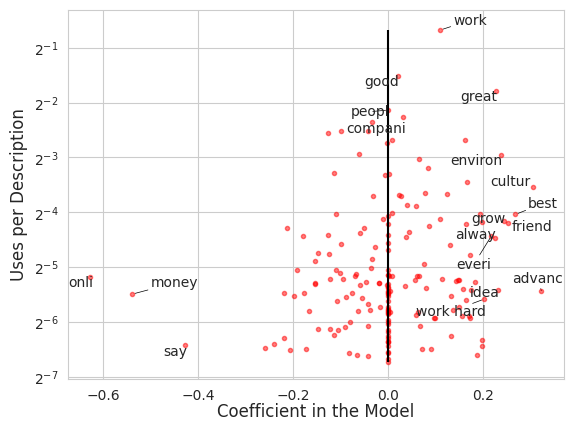

In [280]:
#### Pros coefficient plot
# combine variable names and list of coefficients
coefs = list(zip(list(amazon_dfm_train_pros), list(clf_pros.coef_)))
print(coefs)

coefs = pd.DataFrame(coefs, columns = ['ngrams', 'score'])
print(coefs)

# we can do something similar with
freq = pd.DataFrame([list(amazon_dfm_train_pros), amazon_dfm_train_pros.mean()], index = ['ngrams', 'freq']).T

pros_model = pd.merge(coefs, freq, how = 'left', on = 'ngrams')
pros_model = pros_model[(pros_model['score'] != 0) | (pros_model['ngrams'] != 'intercept')]
pros_model = pros_model.dropna()


sns.set_style("whitegrid")
fig, ax = plt.subplots()

# plot points
ax.plot(pros_model['score'], pros_model['freq'], color = 'r', alpha = 0.5, linestyle='', marker='o', markersize=3)

# log-transform the Y axis so it's not compressed at the bottom
ax.set_yscale('log', base=2)

# manually set axis ticks depending on data range
# ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])

# select top correlations/frequency
top_words = pros_model[(pros_model['score'] > 0.2) | (pros_model['freq'] > .2)]

# select bottom correlations/frequency
bottom_words = pros_model[(pros_model['score'] < -0.4) & (pros_model['freq'] < .5)]

all_labels = pd.concat([top_words, bottom_words])

x_lab_points = all_labels['score'].tolist()
y_lab_points = all_labels['freq'].tolist()
ngrams = all_labels['ngrams'].tolist()

texts = [ax.text(x_lab_points[i], y_lab_points[i], ngrams[i]) for i in range(len(ngrams))]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )

ax.vlines(x=0, ymin=min(pros_model['freq']), ymax=max(pros_model['freq']), colors='black')

plt.xlabel("Coefficient in the Model", fontsize = 12, labelpad=0.05)
plt.ylabel("Uses per Description", fontsize = 12)
plt.show()

[('job', -0.07332902409620264), ('work hard', -0.06833198748758071), ('amazon', 0.08456416837993559), ('posit', 0.024426674197350666), ('alway', -0.0), ('life balanc', -0.0065291754555614374), ('work environ', -0.3407639622648633), ('oper', -0.0), ('year', -0.06445122613400794), ('direct', 0.0), ('area', 0.10642381049778465), ('build', -0.0), ('depend', 0.2504215213862259), ('product', -0.0), ('cut', -0.05250071357048659), ('hard work', -0.044951312345669625), ('improv', 0.15795332517974456), ('respons', -0.2176792679027375), ('say', -0.059518457742338), ('differ', 0.0), ('friend', 0.0), ('start', -0.11903568128410538), ('abl', 0.0), ('becaus', -0.0), ('realli', 0.10508249456088209), ('need', 0.06046581729588329), ('just', -0.011162882225858381), ('season', 0.07327299384612561), ('project', -0.10847439677881228), ('work amazon', -0.07238373686580311), ('advanc', -0.2761691462085031), ('food', 0.009932733589989693), ('ll', 0.30387773537586077), ('quick', 0.0), ('good', 0.0), ('place', 0

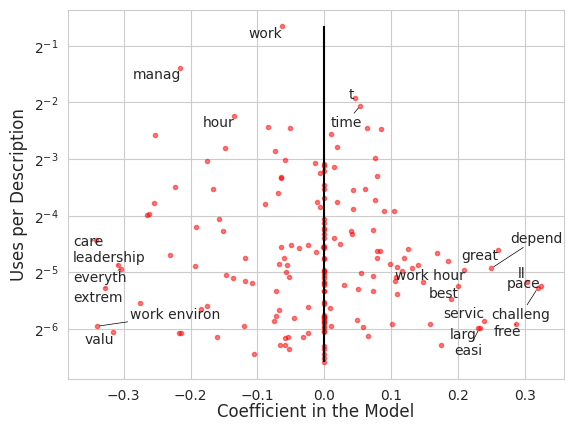

In [281]:
#### Cons coefficient plot

# combine variable names and list of coefficients
coefs = list(zip(list(amazon_dfm_train_cons), list(clf_cons.coef_)))
print(coefs)

coefs = pd.DataFrame(coefs, columns = ['ngrams', 'score'])
print(coefs)

# we can do something similar with
freq = pd.DataFrame([list(amazon_dfm_train_cons), amazon_dfm_train_cons.mean()], index = ['ngrams', 'freq']).T

cons_model = pd.merge(coefs, freq, how = 'left', on = 'ngrams')
cons_model = cons_model[(cons_model['score'] != 0) | (cons_model['ngrams'] != 'intercept')]
cons_model = cons_model.dropna()


sns.set_style("whitegrid")
fig, ax = plt.subplots()

# plot points
ax.plot(cons_model['score'], cons_model['freq'], color = 'r', alpha = 0.5, linestyle='', marker='o', markersize=3)

# log-transform the Y axis so it's not compressed at the bottom
ax.set_yscale('log', base=2)

# manually set axis ticks depending on data range
# ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])

# select top correlations/frequency
top_words = cons_model[(cons_model['score'] > 0.2) | (cons_model['freq'] > .2)]

# select bottom correlations/frequency
bottom_words = cons_model[(cons_model['score'] < -0.3) & (cons_model['freq'] < .5)]

all_labels = pd.concat([top_words, bottom_words])

x_lab_points = all_labels['score'].tolist()
y_lab_points = all_labels['freq'].tolist()
ngrams = all_labels['ngrams'].tolist()

texts = [ax.text(x_lab_points[i], y_lab_points[i], ngrams[i]) for i in range(len(ngrams))]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )

ax.vlines(x=0, ymin=min(cons_model['freq']), ymax=max(cons_model['freq']), colors='black')

plt.xlabel("Coefficient in the Model", fontsize = 12, labelpad=0.05)
plt.ylabel("Uses per Description", fontsize = 12)
plt.show()

In [282]:
gd_amazon_test = pd.DataFrame()

gd_amazon_test['prediction_cons'] = test_predict_amazon_cons
gd_amazon_test['error_cons'] = abs(y_test_amazon.to_list() - gd_amazon_test['prediction_cons'])
gd_amazon_test['prediction_pros'] = test_predict_amazon_cons
gd_amazon_test['error_pros'] = abs(y_test_amazon.to_list() - gd_amazon_test['prediction_pros'])
gd_amazon_test['overall'] = y_test_amazon.to_list()
gd_amazon_test['text'] = gd_amazon.iloc[test_index]['pros'].to_list()

close_high_pros = gd_amazon_test[(gd_amazon_test['overall'] == 5) & (gd_amazon_test['error_pros'] > 1)].iloc[:2]
close_low_pros = gd_amazon_test[(gd_amazon_test['overall'] == 1) & (gd_amazon_test['error_pros'] < 2)].iloc[:2]

close_high_cons = gd_amazon_test[(gd_amazon_test['overall'] == 5) & (gd_amazon_test['error_cons'] < 1)].iloc[:2]
close_low_cons = gd_amazon_test[(gd_amazon_test['overall'] == 1) & (gd_amazon_test['error_cons'] < 2)].iloc[:2]

print(close_high_pros['text'])
print(close_high_cons['text'])

0    Work Life balance with work flexibility, Inter...
1    Opportunity to work with lots of super smart p...
Name: text, dtype: object
313    AWS - Well structured, 40hr/wk, great attitude...
530    Amazon Web Services has a fast-moving, focused...
Name: text, dtype: object


Changing to tri-grams and repeating

In [283]:
# To change to tri-gram, set ngram_range = (2,3)
gd_amazon = gd_small[gd_small['company'] == 'amazon']

# create our prediction variables
dfm_amazon_pros = TAB_dfm(gd_amazon['pros'], ngrams_range = (2,3))

# Randomly choose 50% for test and 50% for training data
sss = ShuffleSplit(n_splits=1, test_size=0.5)

y_amazon = gd_amazon['overall']
X_amazon_pros = dfm_amazon_pros

sss.get_n_splits(X_amazon_pros, y_amazon)
train_index, test_index = next(sss.split(X_amazon_pros, y_amazon))

X_train_amazon_pros, X_test_amazon_pros = X_amazon_pros.iloc[train_index], X_amazon_pros.iloc[test_index]
y_train_amazon, y_test_amazon = y_amazon.iloc[train_index], y_amazon.iloc[test_index]

# The below is for when we don't have to to any transfer learning
# X_train_amazon_pros, X_test_amazon_pros, y_train_amazon_pros, y_test_amazon_pros = train_test_split(
#     X_amazon_pros, y_amazon, test_size=0.5, random_state=42)

# Put training data into LASSO model
clf_pros = Lasso(alpha = 0.001)

clf_pros.fit(X_train_amazon_pros, y_train_amazon)
test_predict_amazon_pros = clf_pros.predict(X_test_amazon_pros)

# Estimate accuracy
pro_acc = kendall_acc(test_predict_amazon_pros, y_test_amazon)
print(pro_acc)


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

     acc  lower  upper
0  59.62  58.28  60.95


[('benefit good', -0.032043350537026484), ('compani work', 0.20021544678099046), ('custom obsess', 0.23714636521904048), ('decent pay', -0.3722202821147481), ('don t', -0.19170696577965035), ('dress code', -0.0), ('everi day', 0.5815172038287028), ('fast pace', 0.2622393232982993), ('fast pace environ', 0.0), ('flexibl work', 0.44426374208903285), ('good benefit', -0.15305458627240645), ('good pay', -0.12729872101781697), ('good peopl', -0.053700026838765236), ('good place', 0.0), ('good salari', 0.05340180721001635), ('good work', 0.09512012808491753), ('great benefit', 0.08370037388067401), ('great compani', 0.3719882446734335), ('great opportun', 0.33115537628628094), ('great pay', 0.02800721330316409), ('great peopl', 0.4829642178213784), ('great place', 0.0823658260020385), ('great place work', -0.0), ('great work', 0.40755708231686644), ('growth opportun', 0.4027050712442847), ('hard work', 0.1712285894148774), ('leadership principl', 0.4727332619563998), ('learn lot', -0.0), ('l

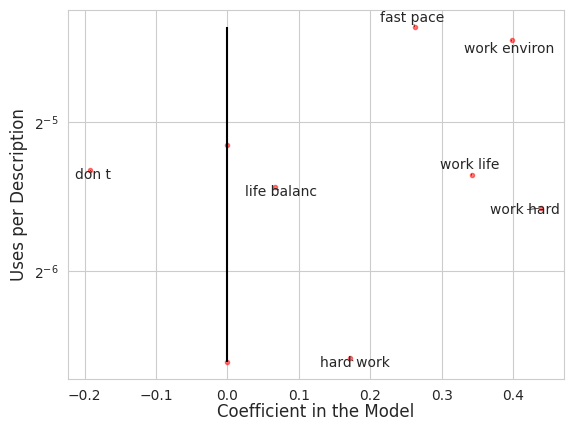

In [284]:
#### Pros coefficient plot
# combine variable names and list of coefficients
coefs = list(zip(list(X_train_amazon_pros), list(clf_pros.coef_)))
print(coefs)

coefs = pd.DataFrame(coefs, columns = ['ngrams', 'score'])
print(coefs)

# we can do something similar with
freq = pd.DataFrame([list(amazon_dfm_train_pros), amazon_dfm_train_pros.mean()], index = ['ngrams', 'freq']).T

pros_model = pd.merge(coefs, freq, how = 'left', on = 'ngrams')
pros_model = pros_model[(pros_model['score'] != 0) | (pros_model['ngrams'] != 'intercept')]
pros_model = pros_model.dropna()

sns.set_style("whitegrid")
fig, ax = plt.subplots()

# plot points
ax.plot(pros_model['score'], pros_model['freq'], color = 'r', alpha = 0.5, linestyle='', marker='o', markersize=3)

# log-transform the Y axis so it's not compressed at the bottom
ax.set_yscale('log', base=2)

# manually set axis ticks depending on data range
# ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])

# select top correlations/frequency
top_words = pros_model[(pros_model['score'] > 0) | (pros_model['freq'] > .2)]

# select bottom correlations/frequency
bottom_words = pros_model[(pros_model['score'] < 0) & (pros_model['freq'] < .5)]

all_labels = pd.concat([top_words, bottom_words])

x_lab_points = all_labels['score'].tolist()
y_lab_points = all_labels['freq'].tolist()
ngrams = all_labels['ngrams'].tolist()

texts = [ax.text(x_lab_points[i], y_lab_points[i], ngrams[i]) for i in range(len(ngrams))]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )
ax.vlines(x=0, ymin=min(pros_model['freq']), ymax=max(pros_model['freq']), colors='black')

plt.xlabel("Coefficient in the Model", fontsize = 12, labelpad=0.05)
plt.ylabel("Uses per Description", fontsize = 12)
plt.show()

In [285]:
# Repeat for cons
dfm_amazon_cons = TAB_dfm(gd_amazon['cons'], ngrams_range = (2,3))

# Randomly choose 50% for test and 50% for training data
X_amazon_cons = dfm_amazon_cons

X_train_amazon_cons, X_test_amazon_cons = X_amazon_cons.iloc[train_index], X_amazon_cons.iloc[test_index]

# Put training data into LASSO model
clf_cons = Lasso(alpha = 0.001)

clf_cons.fit(X_train_amazon_cons, y_train_amazon)
test_predict_amazon_cons = clf_cons.predict(X_test_amazon_cons)

# Estimate accuracy
con_acc = kendall_acc(test_predict_amazon_cons, y_test_amazon)
print(con_acc)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

     acc  lower  upper
0  58.87  57.54  60.21


[('aren t', 0.06499955204763957), ('didn t', -0.3048235844021737), ('doesn t', -0.4181242517427341), ('don t', -0.29657525197658136), ('dure peak', 0.07070102838527023), ('fast pace', 0.35507524174119504), ('feel like', -0.026244917994564302), ('hard work', -0.24394215941049407), ('hour day', -0.16608020348501432), ('hour shift', -0.3794170432573624), ('hour week', -0.3938200025698651), ('hour work', -0.10503776351530036), ('isn t', 0.0), ('life balanc', -0.15229992483589816), ('long hour', -0.11575351190376078), ('mandatori overtim', -0.3260563912308513), ('peak season', -0.05063818147234892), ('t care', -0.8201296345463583), ('t know', -0.0), ('veri littl', -0.5435514548324527), ('won t', -0.061807022044127045), ('work amazon', -0.5395703488092846), ('work environ', -0.6558530214364132), ('work hard', -0.11035689636589494), ('work hour', -0.17989383835868242), ('work life', -0.09712143461063188), ('work life balanc', -0.08306264802906628)]
               ngrams     score
0           

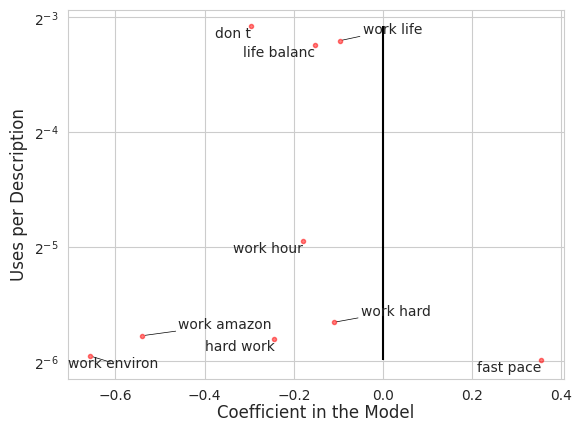

In [286]:
#### Cons coefficient plot

# combine variable names and list of coefficients
coefs = list(zip(list(X_train_amazon_cons), list(clf_cons.coef_)))
print(coefs)

coefs = pd.DataFrame(coefs, columns = ['ngrams', 'score'])
print(coefs)

# we can do something similar with
freq = pd.DataFrame([list(amazon_dfm_train_cons), amazon_dfm_train_cons.mean()], index = ['ngrams', 'freq']).T

cons_model = pd.merge(coefs, freq, how = 'left', on = 'ngrams')
cons_model = cons_model[(cons_model['score'] != 0) | (cons_model['ngrams'] != 'intercept')]
cons_model = cons_model.dropna()


sns.set_style("whitegrid")
fig, ax = plt.subplots()

# plot points
ax.plot(cons_model['score'], cons_model['freq'], color = 'r', alpha = 0.5, linestyle='', marker='o', markersize=3)

# log-transform the Y axis so it's not compressed at the bottom
ax.set_yscale('log', base=2)

# manually set axis ticks depending on data range
# ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])

# select top correlations/frequency
top_words = cons_model[(cons_model['score'] > 0) | (cons_model['freq'] > .2)]

# select bottom correlations/frequency
bottom_words = cons_model[(cons_model['score'] < 0) & (cons_model['freq'] < .5)]

all_labels = pd.concat([top_words, bottom_words])

x_lab_points = all_labels['score'].tolist()
y_lab_points = all_labels['freq'].tolist()
ngrams = all_labels['ngrams'].tolist()

texts = [ax.text(x_lab_points[i], y_lab_points[i], ngrams[i]) for i in range(len(ngrams))]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )

ax.vlines(x=0, ymin=min(cons_model['freq']), ymax=max(cons_model['freq']), colors='black')

plt.xlabel("Coefficient in the Model", fontsize = 12, labelpad=0.05)
plt.ylabel("Uses per Description", fontsize = 12)
plt.show()

Build model for microsoft

In [287]:

gd_msft = gd_small[gd_small['company'] == 'microsoft']

# create our prediction variables
dfm_msft_pros = TAB_dfm(gd_msft['pros'], ngrams_range = (1,2))

# Randomly choose 50% for test and 50% for training data
sss = ShuffleSplit(n_splits=1, test_size=0.5)

y_msft = gd_msft['overall']
X_msft_pros = dfm_msft_pros

sss.get_n_splits(X_msft_pros, y_msft)
train_index, test_index = next(sss.split(X_msft_pros, y_msft))

X_train_msft_pros, X_test_msft_pros = X_msft_pros.iloc[train_index], X_msft_pros.iloc[test_index]
y_train_msft, y_test_msft = y_msft.iloc[train_index], y_msft.iloc[test_index]

# The below is for when we don't have to to any transfer learning
# X_train_amazon_pros, X_test_amazon_pros, y_train_amazon_pros, y_test_amazon_pros = train_test_split(
#     X_amazon_pros, y_amazon, test_size=0.5, random_state=42)

# Put training data into LASSO model
clf_msft_pros = Lasso(alpha = 0.001)

clf_msft_pros.fit(X_train_msft_pros, y_train_msft)
test_predict_msft_pros = clf_msft_pros.predict(X_test_msft_pros)

# Estimate accuracy
pro_acc = kendall_acc(test_predict_msft_pros, y_test_msft)
print(pro_acc)


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

     acc  lower  upper
0  60.99  59.43  62.56


In [288]:
# Training model on microsoft data but predicting amazon


col_heads_msft_pros = set(dfm_msft_pros)
col_heads_amazon_pros = set(dfm_amazon_pros)

col_heads = col_heads_msft_pros.intersection(col_heads_amazon_pros)
print(col_heads)

# Training data from microsoft but subset microsoft data for where text appears in both microsoft and amazon

msft_dfm_train_pros = X_train_msft_pros[col_heads]
msft_dfm_test_pros = X_test_msft_pros[col_heads]

X_train_amazon_pros, X_test_amazon_pros = X_amazon_pros.iloc[train_index], X_amazon_pros.iloc[test_index]
y_train_amazon, y_test_amazon = y_amazon.iloc[train_index], y_amazon.iloc[test_index]

amazon_dfm_train_pros = X_train_amazon_pros[col_heads]
amazon_dfm_test_pros = X_test_amazon_pros[col_heads]


# test on amazon
clf_amazon_pros = Lasso(alpha = 0.001)
clf_amazon_pros.fit(amazon_dfm_train_pros, y_train_msft)
test_predict_amazon_pros = clf_amazon_pros.predict(msft_dfm_test_pros)

# Estimate accuracy
pros_acc_c = kendall_acc(test_predict_amazon_pros, y_test_msft)
print(pros_acc_c)

{'learn lot', 'work hour', 'great opportun', 'life balanc', 'work environ', 'good peopl', 'pay good', 'lot opportun', 'work cultur', 'work life', 'flexibl work', 'great peopl', 'smart peopl', 'opportun work', 'great benefit', 'good work', 'veri good', 'benefit good', 'great place', 'place work', 'good place', 'work veri', 'great pay', 'great compani', 'veri smart', 'compani work', 'opportun learn', 'work home', 'good salari', 'work great', 'good pay', 'pay benefit', 'peopl work', 'great work', 'good benefit', 'don t'}
     acc  lower  upper
0  47.16  45.56  48.76


<ipython-input-288-2e0ee697bdff>:12: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  msft_dfm_train_pros = X_train_msft_pros[col_heads]
<ipython-input-288-2e0ee697bdff>:13: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  msft_dfm_test_pros = X_test_msft_pros[col_heads]
<ipython-input-288-2e0ee697bdff>:18: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  amazon_dfm_train_pros = X_train_amazon_pros[col_heads]
<ipython-input-288-2e0ee697bdff>:19: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  amazon_dfm_test_pros = X_test_amazon_pros[col_heads]
